In [1]:
import random
import numpy as np
import torch
import torch.nn.init as init
import matplotlib.pyplot as plt
from PIL import Image
from skimage import data
import cv2


# DATA MANIPULATION

In [15]:
# Creare un row-vector (tensore) contenente i primi 12 interi (float by default) partendo da 0
x = torch.arange(12)

# con la proprietà .shape si accede alla lunghezza su ogni asse
print("x shape", x.shape)

# con il metodo .numel() si accede al numero totale di elementi nel tensore
print("x numero elementi", x.numel())

# per cambiare la shape del tensore senza alterare il numero di elementi si invoca il metodo .reshape()
X = x.reshape(3, 4)     # ora X è una matrice 3x4
Y = x.reshape(2, -1)    # la seconda dimensione verrà automaticamente calcolata

print("X shape", X.shape)
print("Y shape", Y.shape)


x shape torch.Size([12])
x numero elementi 12
X shape torch.Size([3, 4])
Y shape torch.Size([2, 6])


In [21]:
# Si possono creare tensori con una data shape i cui elementi sono: 
# zeri, uno, valori random oppure valori specificati

# Doppia parentesi tonda per le dimensioni > 2!!
print(torch.zeros((2, 3, 4)), '\n')
print(torch.ones((2, 3, 4)), '\n')
print(torch.randn(3, 4), '\n')

# Da notare il numero di parentesi quadre: quelle interne sono le righe della matrice
print(torch.tensor([[2, 1, 4, 3], [1, 2, 3, 4], [4, 3, 2, 1]]))

tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]]) 

tensor([[[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]],

        [[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]]) 

tensor([[-0.2282, -1.4581,  0.7687,  0.0259],
        [ 0.5510,  0.6105,  1.2912,  0.6921],
        [-3.4441, -0.6116, -0.2655, -0.3395]]) 

tensor([[2, 1, 4, 3],
        [1, 2, 3, 4],
        [4, 3, 2, 1]])


In [ ]:
# ELEMENT-WISE OPERATIONS
# Queste operazioni applicano un'operatore scalare ad ogni elemento del tensore
# cioè tra ogni coppia corrispondente di elementi tra i due tensori

x = torch.tensor([1.0, 2, 4, 8])
y = torch.tensor([2, 2, 2, 2])

# Questi operatori sono element-wise (binari) per ogni coppia di tensori che hanno la stessa shape
# Cioè applicano l'operatore ad ogni coppia di elementi corrispondenti
print("x + y", x + y)
print("x - y", x - y)
print("x * y", x * y)
print("x / y", x / y)

x + y tensor([ 3.,  4.,  6., 10.])
x - y tensor([-1.,  0.,  2.,  6.])
x * y tensor([ 2.,  4.,  8., 16.])
x / y tensor([0.5000, 1.0000, 2.0000, 4.0000])


In [ ]:
# FUNZIONI DI RIDUZIONE (.sum(), .mean(), .max(), .avg() ...)
A = torch.arange(20, dtype=torch.float32).reshape(5, 4)
print(A, '\n')

# somma di tutti gli elementi del tensore
print("Somma:", A.sum(), '\n')

# somma lungo l'asse 0: cioè somma di ogni colonna
print("Somma asse 0 (colonne):", A.sum(axis=0), '\n')  

# somma lungo l'asse 1: cioè somma di ogni riga
print("Somma asse 1 (righe):", A.sum(axis=1), '\n')

# Negli ultimi due casi i risultati sono sempre dei tensori ma RIDOTTI di una dimensione
# Nel caso seguente invece si mantiene la stessa dimensione del tensore originale: utile per il BROADCASTING (vedi dopo)
print("Somma lungo le righe mantenendo la stessa dimensione:")
print(A.sum(axis=1, keepdims=True), '\n')

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.],
        [12., 13., 14., 15.],
        [16., 17., 18., 19.]]) 

Somma: tensor(190.) 

Somma asse 0 (colonne): tensor([40., 45., 50., 55.]) 

Somma asse 1 (righe): tensor([ 6., 22., 38., 54., 70.]) 

Somma lungo le righe mantenendo la stessa dimensione
tensor([[ 6.],
        [22.],
        [38.],
        [54.],
        [70.]]) 



In [ ]:
# DOT-PRODUCT
# Il dot-product, dati due vettori, è la somma sui prodotti degli elementi corrispondenti 
# cioè elementi nella stessa posizione.
# Dot-Product = element-wise multiplication + sum

y = torch.ones(4, dtype = torch.float32)    # [1, 1, 1, 1]
x = torch.arange(4, dtype = torch.float32)  # [0, 1, 2, 3]

x, y, torch.dot(x, y)
torch.sum(x * y)    # equivalente
(x * y).sum()       # equivalente

tensor(6.)

In [ ]:
# CONCATENATION

X = torch.arange(12, dtype=torch.float32).reshape(3, 4)
Y = torch.tensor([[2.0, 1, 4, 3], [1, 2, 3, 4], [4, 3, 2, 1]])

print(torch.cat((X, Y), dim=0), "\n")    # concatenazione lungo l'asse 0  (aggiunge righe)
print(torch.cat((X, Y), dim=1), "\n")    # concatenazione lungo l'asse 1 (aggiunge colonne)

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.],
        [ 2.,  1.,  4.,  3.],
        [ 1.,  2.,  3.,  4.],
        [ 4.,  3.,  2.,  1.]]) 

tensor([[ 0.,  1.,  2.,  3.,  2.,  1.,  4.,  3.],
        [ 4.,  5.,  6.,  7.,  1.,  2.,  3.,  4.],
        [ 8.,  9., 10., 11.,  4.,  3.,  2.,  1.]]) 



In [25]:
# INDEXING
X = torch.arange(12, dtype=torch.uint8)
print(X, '\n')
print(X[1:3], '\n')     # stampa da indice 1 a indice 3 (escluso)
print( X[-1], '\n')     # stampa l'ultimo elemento

X = X.reshape(3, 4)
print(X, '\n')
print(X[0:2, :], '\n')   # stampa le prime 2 righe (elementi da 0 a 2 escluso + tutte le colonne) == print(X[:2, :], '\n')
                         # analogamente per le colonne

# Le scritture precedenti non creano un nuovo tensore ma restituiscono una VIEW (vista)
# del tensore originale

# view di X con shape (2, 4) e stride (2, 2)
# cioè, lo stride (2, 2) indica che per spostarsi da una riga all'altra si devono saltare 2 elementi 
# e per spostarsi da una colonna all'altra si devono saltare 2 elementi
print(torch.as_strided(X, (2, 4), (2, 2)), '\n') 

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11], dtype=torch.uint8) 

tensor([1, 2], dtype=torch.uint8) 

tensor(11, dtype=torch.uint8) 

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]], dtype=torch.uint8) 

tensor([[0, 1, 2, 3],
        [4, 5, 6, 7]], dtype=torch.uint8) 

tensor([[0, 2, 4, 6],
        [2, 4, 6, 8]], dtype=torch.uint8) 



In [28]:
# NUMPY BRIDGE
# convertire un tensore in un array Numpy e viceversa

a = torch.ones(5)
c = a.numpy()

a +=1

print(a)
print(c)

print('\n')

# viceversa
a = np.ones((5,))
c = torch.from_numpy(a)

a += 2

print(a)
print(c)


tensor([2., 2., 2., 2., 2.])
[2. 2. 2. 2. 2.]


[3. 3. 3. 3. 3.]
tensor([3., 3., 3., 3., 3.], dtype=torch.float64)


#### BROADCASTING

In [ ]:
# Serve per implementare la Convoluzione o il Pooling:
# è un meccanismo che permette di fare operazioni element-wise tra array/tensori di dimensioni diverse
# senza doverli espandere manualmente. Python espande automaticamente il tensore più piccolo
# per far combaciare le dimensioni ed applicare l'operazione elemento per elemento

# Nell'esempio sotto viene eseguito il broadcasting su "c", che diventa
# [[0, 1],
#  [0, 1],
#  [0, 1]]

# In particolare:
# 1) se gli array non hanno lo stesso rank (numero di dimensioni), quello con rank inferiore viene
#    espanso con dimensioni di 1 fino ad avere lo stesso rank dell'altro array
# 2) due array sono compatibili in una dimensione se hanno la stessa grandezza in quella dimensione
#    o se uno dei due array ha grandezza 1 in quella dimensione
# 3) in ogni dimensione dove 1 array ha grandezza 1 e l'altro ha grandezza maggiore, il primo array
#    si comporta come se fosse stato replicato lungo quella dimensione

In [4]:
a =torch.arange(3).reshape((3, 1))
print(a)

tensor([[0],
        [1],
        [2]])


In [5]:
c = torch.arange(2).reshape((1, 2))
print(c)

tensor([[0, 1]])


In [ ]:
# Broadcasting: 
a + c

tensor([[0, 1],
        [1, 2],
        [2, 3]])

# 2D-CONVOLUTION

#### RANDOM GENERATED IMAGE & KERNEL

In [4]:
# Set-up code
n = random.randint(2, 6)
iC = random.randint(2, 6)
oC = random.randint(2, 6)
H = random.randint(10, 20)
W = random.randint(10, 20)
kH = random.randint(2, 6)
kW = random.randint(2, 6)

input = torch.rand(n, iC, H, W, dtype=torch.float32)
kernel = torch.rand(oC, iC, kH, kW, dtype=torch.float32)

print("n:", n, "//", "iC:", iC, "//", "oC:", oC, "//", "H:", H, "//", "W:", W, "//", "kH:", kH, "//", "kW:", kW)

n: 6 // iC: 4 // oC: 4 // H: 17 // W: 18 // kH: 6 // kW: 4


In [5]:
# input shape: (n, iC, H, W)
print("input shape:", input.shape)

# kernel shape: (oC, iC, kH, kW)
print("kernel shape:", kernel.shape)

input shape: torch.Size([6, 4, 17, 18])
kernel shape: torch.Size([4, 4, 6, 4])


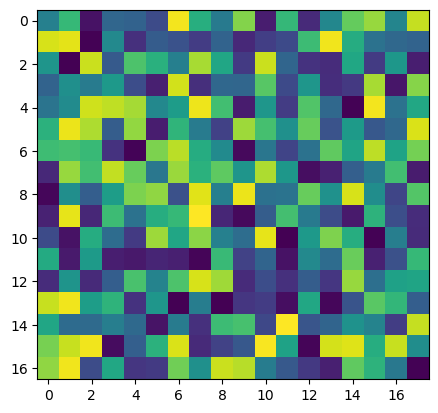

In [7]:
# INPUT
plt.imshow(input[0, 0].numpy())

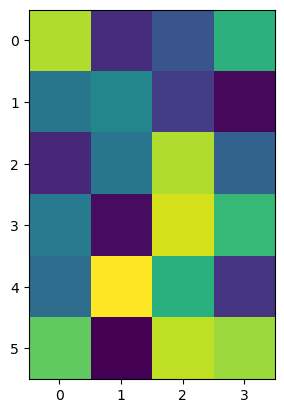

In [8]:
# KERNEL
plt.imshow(kernel[0, 0].numpy())

In [9]:
# Aggiunge una dimensione nella posizione specificata (1 = second position, 0 = first position)
input.unsqueeze_(1).shape
kernel.unsqueeze_(0).shape


# input shape: (n, 1, iC, H, W)
print("input shape:", input.shape)

# kernel shape: (1, oC, iC, kH, kW)
print("kernel shape:", kernel.shape)

input shape: torch.Size([6, 1, 4, 17, 18])
kernel shape: torch.Size([1, 4, 4, 6, 4])


In [ ]:
# Uso il Broadcasting per la CONVOLUZIONE
oH = H - kH + 1
oW = W - kW + 1

out = torch.zeros(n, oC, oH, oW)

for r in range(oH):
    for c in range(oW):
        # Prendo tutte le immagini (n), prendo tutti gli oC, prendo tutti gli iC
        # Indicizzo e scorro solo su W ed H
        # Faccio la somma solo su iC, H e W --> è come funziona la convoluzione
        out[..., r, c] = (input[:, :, :, r:r+kH, c:c+kW] * kernel).sum(dim=(2, 3, 4))

In [11]:
# output shape: (n, oC, oH, oW)
print("output shape:", out.shape)

output shape: torch.Size([6, 4, 12, 15])


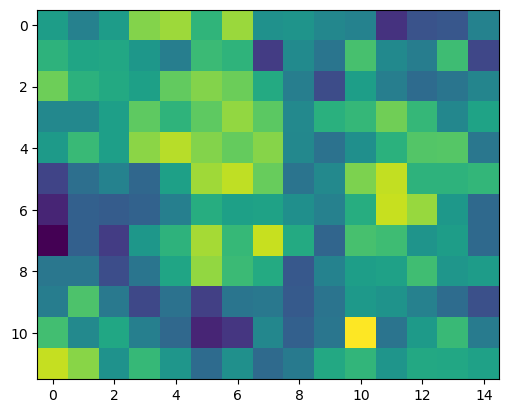

In [12]:
# OUTPUT
plt.imshow(out[0, 0].numpy())

#### REAL IMAGE & KERNEL

In [ ]:
n = random.randint(2, 6)
iC = 3
oC = random.randint(2, 6)
H = 512
W = 512
kH = 5
kW = 5

input = Image.open('lenna.jpg')
kernel = torch.empty((oC,iC,kH,kW))

# Xavier initialization for the kernel
init.kaiming_normal_(kernel)

print("n:", n, "//", "iC:", iC, "//", "oC:", oC, "//", "H:", H, "//", "W:", W, "//", "kH:", kH, "//", "kW:", kW)

n: 4 // iC: 3 // oC: 6 // H: 512 // W: 512 // kH: 5 // kW: 5


In [58]:
# INPUT PRE-PROCESSING
input = torch.from_numpy(np.array(input, dtype=np.float32)).permute(2, 0, 1)
input = input.unsqueeze(0)
input = input.to(torch.float32)

In [59]:
# input shape: (n, iC, H, W)
print("input shape:", input.shape)

# kernel shape: (oC, iC, kH, kW)
print("kernel shape:", kernel.shape)

input shape: torch.Size([1, 3, 512, 512])
kernel shape: torch.Size([6, 3, 5, 5])


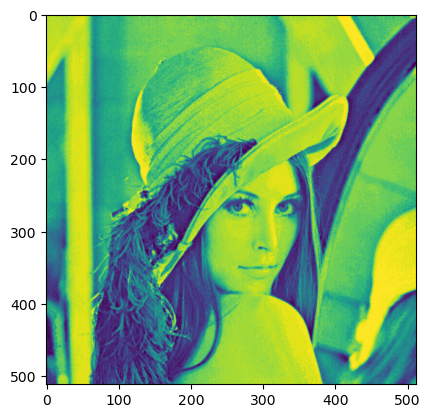

In [60]:
# INPUT
plt.imshow(input[0, 0].numpy())

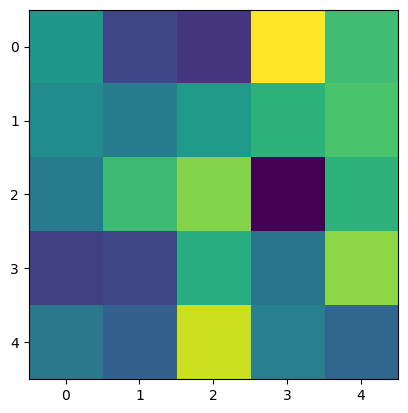

In [61]:
# KERNEL
plt.imshow(kernel[0, 0].numpy())

In [62]:
input.unsqueeze_(1).shape
kernel.unsqueeze_(0).shape

print("input shape:", input.shape)
print("kernel shape:", kernel.shape)

input shape: torch.Size([1, 1, 3, 512, 512])
kernel shape: torch.Size([1, 6, 3, 5, 5])


In [63]:
oH = H - kH + 1
oW = W - kW + 1

out = torch.zeros(n, oC, oH, oW)

for r in range(oH):
    for c in range(oW):
        out[..., r, c] = (input[:, :, :, r:r+kH, c:c+kW] * kernel).sum(dim=(2, 3, 4))
        

In [64]:
# output shape: (n, oC, oH, oW)
print("output shape:", out.shape)

output shape: torch.Size([4, 6, 508, 508])


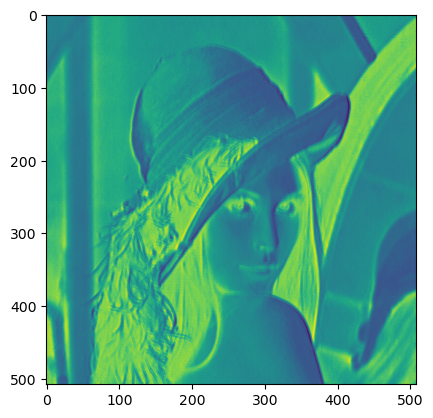

In [65]:
# OUTPUT
plt.imshow(out[0, 0].numpy())

# 3D-POOLING

#### RANDOM GENERATED INPUT

In [80]:
n = random.randint(2, 6)
iC = random.randint(2, 6)
H = random.randint(10, 20)
W = random.randint(10, 20)
kH = random.randint(2, 5)
kW = random.randint(2, 5)
s = random.randint(2, 3)
input = torch.rand((n, iC, H, W), dtype=torch.float32)

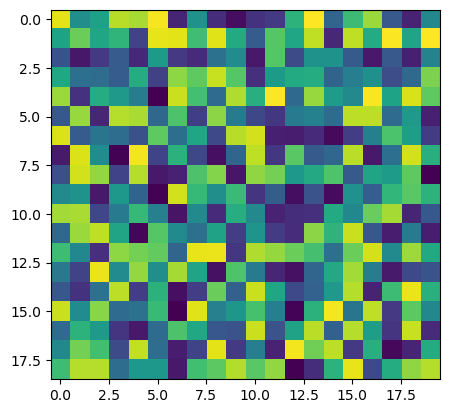

In [81]:
plt.imshow(input[0, 0].numpy())

In [82]:
# input shape: (n, iC, H, W)
print("input shape:", input.shape)

input shape: torch.Size([2, 3, 19, 20])


In [ ]:
oH = (H - kH) // s + 1
oW = (W - kW) // s + 1

out = torch.zeros(n, iC, oH, oW)

for r in range(oH):
    for c in range(oW):
        # Il massimo viene fatto per H e W, mentre non viene fatto su iC
        # Il Max Pooling viene applicato indipendentemente su tutti i canali
        # Moltiplico l'indice di riga e colonna per lo stride per scorrere l'immagine
        out[..., r, c] = (input[:, :, r*s:r*s+kH, c*s:c*s+kW]).amax(dim=(2, 3))

In [ ]:
# output shape: (n, iC, oH, oW)
print("output shape:", out.shape)

output shape: torch.Size([2, 3, 8, 9])


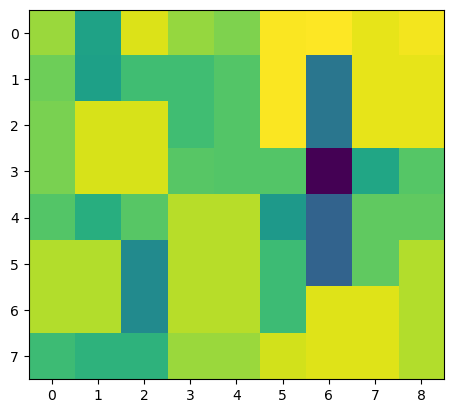

In [ ]:
# OUTPUT
plt.imshow(out[0, 0].numpy())

#### REAL INPUT

In [98]:
n = 1
iC = 3
H = 512
W = 512
kH = 12
kW = 12
s = 3
input = Image.open('lenna.jpg')

In [99]:
# INPUT PRE-PROCESSING
input = torch.from_numpy(np.array(input, dtype=np.float32)).permute(2, 0, 1)
input = input.unsqueeze(0)
input = input.to(torch.float32)

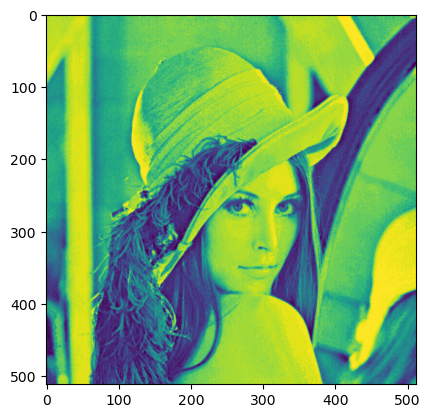

In [100]:
# INPUT
plt.imshow(input[0, 0].numpy())

In [101]:
# input shape: (n, iC, H, W)
print("input shape:", input.shape)

input shape: torch.Size([1, 3, 512, 512])


In [ ]:
oH = (H - kH) // s + 1
oW = (W - kW) // s + 1

out = torch.zeros(n, iC, oH, oW)

for r in range(oH):
    for c in range(oW):
        out[..., r, c] = (input[:, :, r*s:r*s+kH, c*s:c*s+kW]).amax(dim=(2, 3))

In [103]:
# output shape: (n, iC, oH, oW)
print("output shape:", out.shape)

output shape: torch.Size([1, 3, 167, 167])


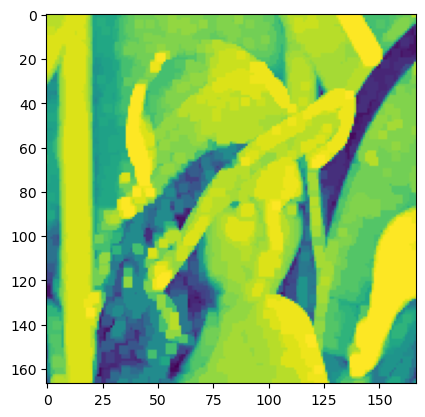

In [104]:
# OUTPUT
plt.imshow(out[0, 0].numpy())

# EDGE-DETECTION

In [39]:
# Set-up code
im = data.gravel()
im = im[:128,:128]
im = torch.from_numpy(im)

In [19]:
# im shape: (H, W)
print("im shape:", im.shape)

im shape: torch.Size([128, 128])


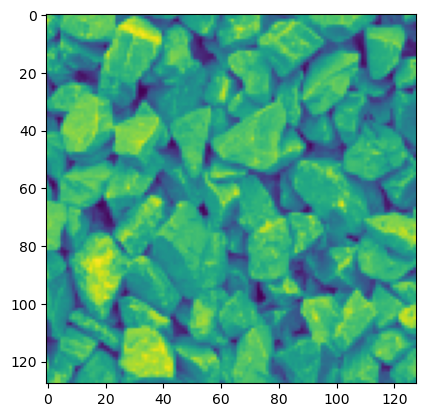

In [20]:
plt.imshow(im.numpy())

In [40]:
# Sobel mask e set-up convoluzione (batch e canali)
Sx = torch.tensor([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=torch.float32)

Sy = torch.tensor([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=torch.float32)


im = im.float()
im.unsqueeze_(0).unsqueeze_(0)

Sx = Sx.unsqueeze(0).unsqueeze(0)
Sy = Sy.unsqueeze(0).unsqueeze(0)

# input shape: (n, iC, H, W)
print("im shape:", im.shape)

# masks shape: (oC, iC, kH, kW)
print("Sx shape:", Sx.shape)
print("Sy shape:", Sy.shape)

im shape: torch.Size([1, 1, 128, 128])
Sx shape: torch.Size([1, 1, 3, 3])
Sy shape: torch.Size([1, 1, 3, 3])


In [ ]:
# CONVOLUZIONE 2D: 
# Immagine e kernel hanno un solo canale!
# Evito la parte di unsqueeze che rende le shape (n, 1, iC, H, W) ed (1, oC, iC, kH, kW)

kH = Sx.shape[2]
kW = Sx.shape[3]

oH = im.shape[2] - kH + 1
oW = im.shape[3] - kW + 1

Imx = torch.zeros(im.shape[0], Sx.shape[0], oH, oW)
Imy = torch.zeros(im.shape[0], Sy.shape[0], oH, oW)


for r in range(oH):
    for c in range(oW):
        Imx[..., r, c] = (im[:, :, r:r+kH, c:c+kW] * Sx).sum(dim=(1, 2, 3))
        
        
for r in range(oH):
    for c in range(oW):
        Imy[..., r, c] = (im[:, :, r:r+kH, c:c+kW] * Sy).sum(dim=(1, 2, 3))

In [42]:
# Imx shape: (n, iC, oH, oW)
print("Imx shape:", Imx.shape)

# Imy shape: (n, iC, oH, oW)
print("Imy shape:", Imy.shape)

Imx shape: torch.Size([1, 1, 126, 126])
Imy shape: torch.Size([1, 1, 126, 126])


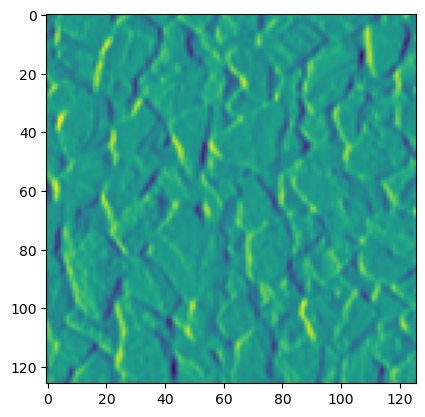

In [ ]:
# IMX
plt.imshow(Imx[0, 0].numpy())

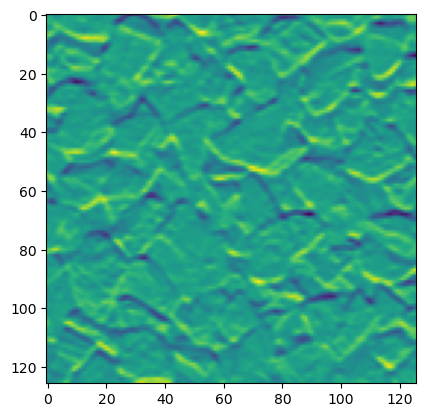

In [45]:
# IMY
plt.imshow(Imy[0, 0].numpy())

In [48]:
# Calcolo la MAGNITUDE e Normalizzo
# In Imx ed Imy ci sono già le DERIVATE dell'immagine lungo x ed y 
# grazie alla maschera applicata

M = torch.sqrt(Imx**2 + Imy**2)
M = M / M.max()

In [ ]:
# Calcolo la DIREZIONE del gradiente usando la funzione nelle slide
# La direzione del vettore gradiente geometricamente si calcola con l'algolo del vettore Imy/Imx:
# np.arctan2 fornisce i valori dell'angolo in tutti e 4 i quadranti --> l'operazione è element-wise (theta[r,c] = atan2(Iy[r,c], Ix[r,c]))

# L'Edge è perpendicolare al gradiente

theta = torch.atan2(Imy, Imx)

In [ ]:
# HSV è uno spazio alternativo ad RGB:
# H (hue) rappresenta il colore, S (saturation) è quanto il colore è "puro", V (value) è la luminosità
# Le slide suggeriscono di mettere la DIREZIONE del gradiente in H (quindi il colore) e la MAGNITUDE in V
# Successivamente convertire in RGB

# H usa valori in [0, 180), quindi devo normalizzare theta che li mostra in [-pi, pi]
theta = (theta + torch.pi) / (2*torch.pi)   # in [0, 1]
H = theta * 180

In [52]:
# H <-- direzione
# S <-- costate
# V <-- magnitude

# H shape (1, 1, 126, 126) --> (126, 126)
# squeeze() rimuove le dimensioni "1" e rende le matrici 2D
H = H.squeeze().numpy()
V = M.squeeze().numpy()

# Matrice della stessa dimensione di H ma con tutti i valori 255 (saturazione massima)
S = np.ones_like(H) * 255

# Normalizza V in valori compresi in [0, 255] per openCV --> prima erano in [0, 1]
Vnorm = V * 255

# Combina le matrici di dimensione (H, W), cioè (126, 126), in una sola matrice 3D
# axis = -1 --> mette i canali alla fine --> (H, W, 3)
HSV = np.stack([H, S, Vnorm], axis=-1).astype(np.uint8)

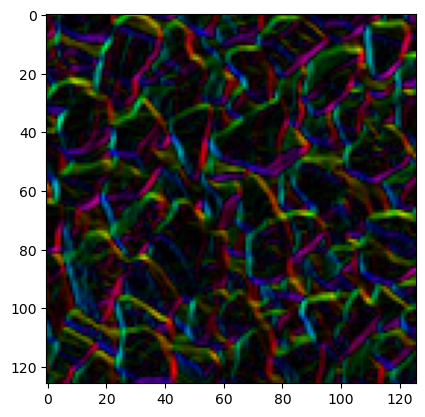

In [ ]:
# Converte l'immagine in RGB (funzione nelle slide)

RGB = cv2.cvtColor(HSV, cv2.COLOR_HSV2RGB)
plt.imshow(RGB)